# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
|Maria Putu Evelyne Corena Puryatma|5054251011|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import warnings
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score)

# NumPy + Accelerate di macOS memunculkan RuntimeWarning palsu saat perkalian matriks; hasilnya tetap benar.
warnings.filterwarnings('ignore', category=RuntimeWarning)
RANDOM_STATE = 42

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv("diabetes.csv")
data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [3]:
print('Jumlah baris dan kolom:', data.shape)
print()
data.info()
print('\nJumlah missing value per kolom:')
print(data.isnull().sum().to_string())
data.describe().T

Jumlah baris dan kolom: (768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Jumlah missing value per kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                    

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Distribusi label Outcome:
Outcome
0    500
1    268

Kelas mayoritas: 0 (65.1% dari seluruh data)


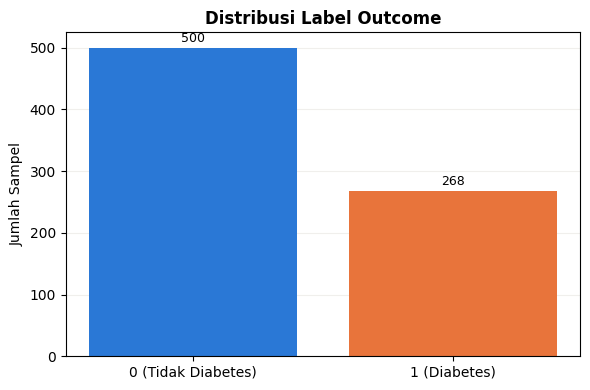

In [4]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
outcome_counts = data['Outcome'].value_counts().sort_index()

print('Distribusi label Outcome:')
print(outcome_counts.to_string())
print(f'\nKelas mayoritas: {outcome_counts.idxmax()} '
      f'({outcome_counts.max() / len(data) * 100:.1f}% dari seluruh data)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['0 (Tidak Diabetes)', '1 (Diabetes)'], outcome_counts.values, color=['#2a78d6', '#e8743b'])
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Label Outcome', fontsize=12, fontweight='bold')
for i, v in enumerate(outcome_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

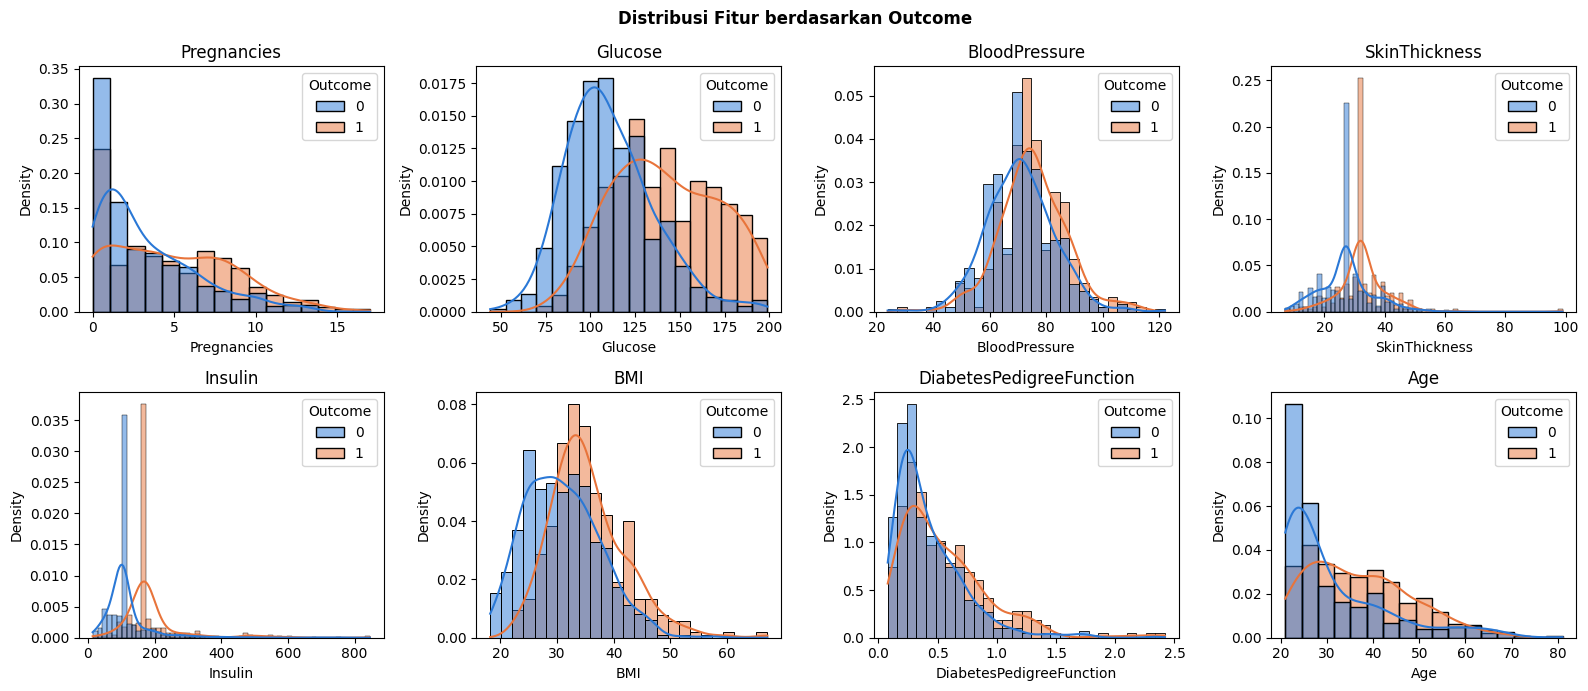

In [5]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = data.columns.drop('Outcome')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    sns.histplot(data=data, x=col, hue='Outcome', kde=True, stat='density',
                 common_norm=False, palette=['#2a78d6', '#e8743b'], ax=ax)
    ax.set_title(col)
plt.suptitle('Distribusi Fitur berdasarkan Outcome', fontweight='bold')
plt.tight_layout()
plt.show()

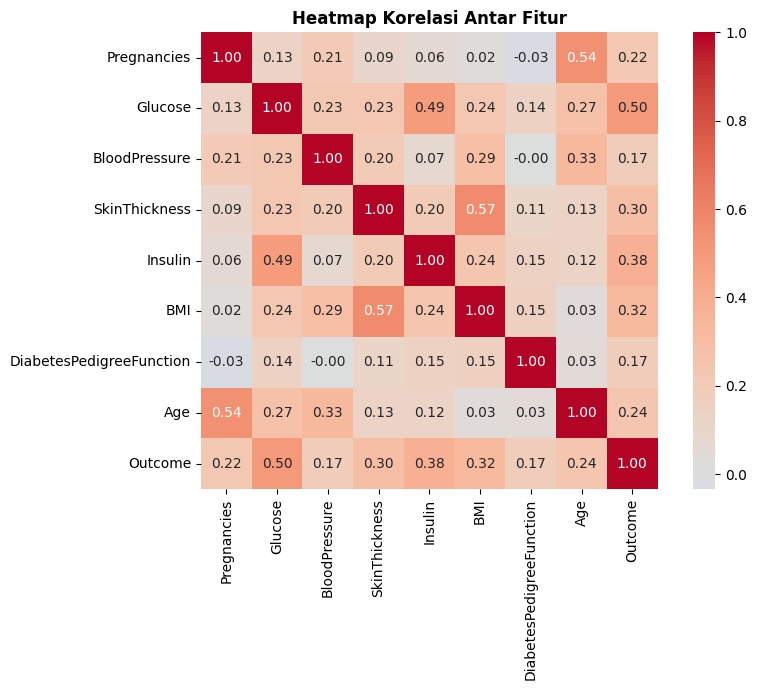

In [6]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(9, 7))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Heatmap Korelasi Antar Fitur', fontweight='bold')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [7]:
# EDA tambahan: rata-rata fitur per kelas Outcome.
data.groupby('Outcome').mean().T.round(2)

Outcome,0,1
Pregnancies,3.30,4.87
Glucose,110.62,142.30
BloodPressure,70.84,75.27
SkinThickness,27.17,32.67
Insulin,117.17,187.62
BMI,30.85,35.40
DiabetesPedigreeFunction,0.43,0.55
Age,31.19,37.07


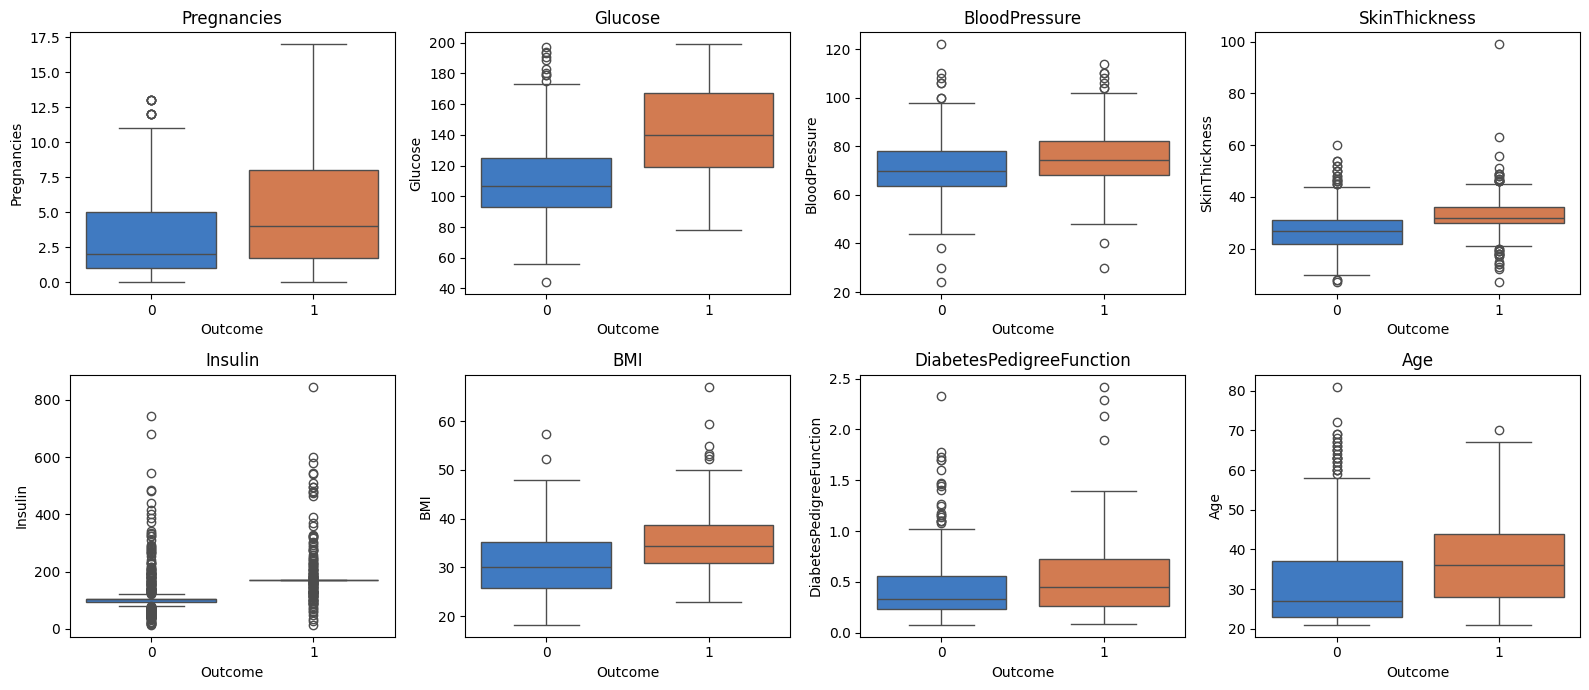

In [8]:
# EDA tambahan: boxplot untuk melihat outlier dan perbedaan sebaran antar kelas.
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    sns.boxplot(data=data, x='Outcome', y=col, hue='Outcome', palette=['#2a78d6', '#e8743b'], legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [9]:
# EDA tambahan: cek apakah nilai 0 sudah diganti oleh penyedia dataset.
# Nilai yang sangat sering muncul pada Insulin dan SkinThickness dicek terhadap Outcome.
print('Nilai paling sering muncul:')
for col in ['Insulin', 'SkinThickness']:
    print(f'  {col}: {data[col].value_counts().head(3).to_dict()}')

print('\nInsulin = 102.5 atau 169.5 vs Outcome:')
print(pd.crosstab(data.loc[data['Insulin'].isin([102.5, 169.5]), 'Insulin'],
                  data.loc[data['Insulin'].isin([102.5, 169.5]), 'Outcome']))

Nilai paling sering muncul:
  Insulin: {102.5: 236, 169.5: 138, 105.0: 11}
  SkinThickness: {27: 162, 32: 119, 30: 27}

Insulin = 102.5 atau 169.5 vs Outcome:
Outcome    0    1
Insulin          
102.5    236    0
169.5      0  138


**Temuan penting:** dataset versi Kaggle ini sudah tidak memiliki nilai 0. Nilai 0 sudah diganti dengan **median per kelas Outcome**.
Contohnya, semua baris dengan Insulin = 102.5 berlabel 0 dan semua baris dengan Insulin = 169.5 berlabel 1 (total 374 baris, sama dengan jumlah nilai 0 Insulin pada dataset Pima asli).
Imputasi yang memakai label seperti ini adalah **data leakage**, karena informasi target "bocor" ke dalam fitur. Pada tahap preprocessing, nilai-nilai ini dikembalikan menjadi missing lalu diimputasi ulang secara benar.

# 2. Preprocessing

In [10]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Jumlah nilai 0 per kolom:')
print((data[zero_cols] == 0).sum().to_string())

Jumlah nilai 0 per kolom:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0


In [11]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df = data.copy()

# 1) Nilai 0 (jika ada) dianggap missing.
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# 2) Kembalikan hasil imputasi median-per-kelas dari penyedia dataset menjadi missing.
#    Insulin 102.5/169.5 adalah nilai pengganti. SkinThickness 27/32 pada baris yang sama juga pengganti.
insulin_filled = df['Insulin'].isin([102.5, 169.5])
df.loc[insulin_filled & df['SkinThickness'].isin([27, 32]), 'SkinThickness'] = np.nan
df.loc[insulin_filled, 'Insulin'] = np.nan

print('Jumlah missing value setelah dikembalikan:')
print(df[zero_cols].isnull().sum().to_string())
# Imputasi median dilakukan SETELAH split, dengan median dari train set saja (lihat cell berikutnya).

Jumlah missing value setelah dikembalikan:
Glucose            0
BloodPressure      0
SkinThickness    247
Insulin          374
BMI                0


In [12]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns='Outcome')
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Imputasi median: median dihitung dari train set saja agar tidak ada data leakage.
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_test = X_test.fillna(train_median)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi kelas 1 -> train: %.3f, test: %.3f' % (y_train.mean(), y_test.mean()))

Train: (614, 8) | Test: (154, 8)
Proporsi kelas 1 -> train: 0.349, test: 0.351


In [13]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [14]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb.predict(X_test_scaled)
y_proba_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [16]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
# Hyperparameter C (kekuatan regularisasi) dan class_weight dipilih dengan 5-fold cross validation pada train set saja.
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced']}
grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid, scoring='accuracy',
                    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
grid.fit(X_train_scaled, y_train)

logreg = grid.best_estimator_
print('Parameter terbaik:', grid.best_params_)
print('Akurasi cross validation (train): %.3f' % grid.best_score_)

Parameter terbaik: {'C': 1, 'class_weight': None}
Akurasi cross validation (train): 0.790


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
results = pd.DataFrame({
    name: {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC AUC': roc_auc_score(y_test, proba),
    }
    for name, pred, proba in [('Gaussian NB', y_pred_gnb, y_proba_gnb),
                              ('Logistic Regression', y_pred_lr, y_proba_lr)]
}).T.round(3)
display(results)

for name, pred in [('Gaussian NB', y_pred_gnb), ('Logistic Regression', y_pred_lr)]:
    print(f'=== {name} ===')
    print(classification_report(y_test, pred, target_names=['Tidak Diabetes', 'Diabetes']))

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Gaussian NB,0.701,0.567,0.63,0.596,0.764
Logistic Regression,0.708,0.600,0.50,0.545,0.813


=== Gaussian NB ===
                precision    recall  f1-score   support

Tidak Diabetes       0.79      0.74      0.76       100
      Diabetes       0.57      0.63      0.60        54

      accuracy                           0.70       154
     macro avg       0.68      0.68      0.68       154
  weighted avg       0.71      0.70      0.70       154

=== Logistic Regression ===
                precision    recall  f1-score   support

Tidak Diabetes       0.75      0.82      0.78       100
      Diabetes       0.60      0.50      0.55        54

      accuracy                           0.71       154
     macro avg       0.68      0.66      0.67       154
  weighted avg       0.70      0.71      0.70       154



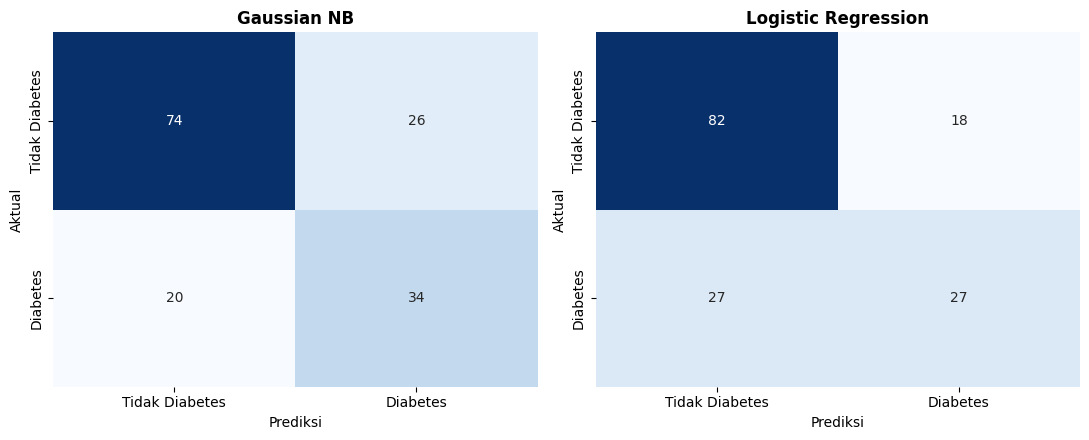

In [19]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [('Gaussian NB', y_pred_gnb), ('Logistic Regression', y_pred_lr)]):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Tidak Diabetes', 'Diabetes'], yticklabels=['Tidak Diabetes', 'Diabetes'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

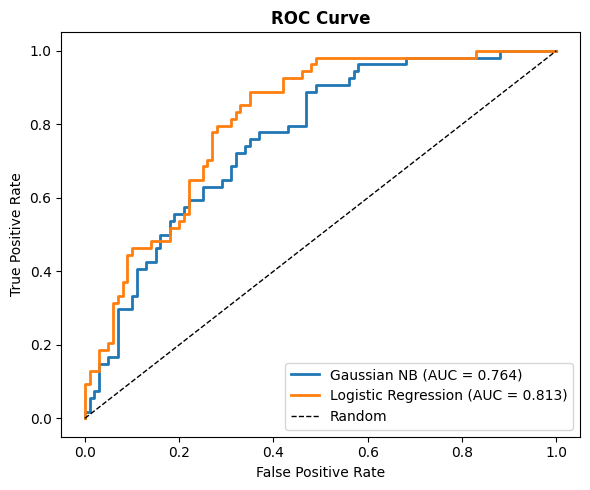

In [20]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(6, 5))
for name, proba in [('Gaussian NB', y_proba_gnb), ('Logistic Regression', y_proba_lr)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Insulin                    -0.069
BloodPressure              -0.026
SkinThickness               0.016
Age                         0.142
DiabetesPedigreeFunction    0.236
Pregnancies                 0.374
BMI                         0.695
Glucose                     1.192


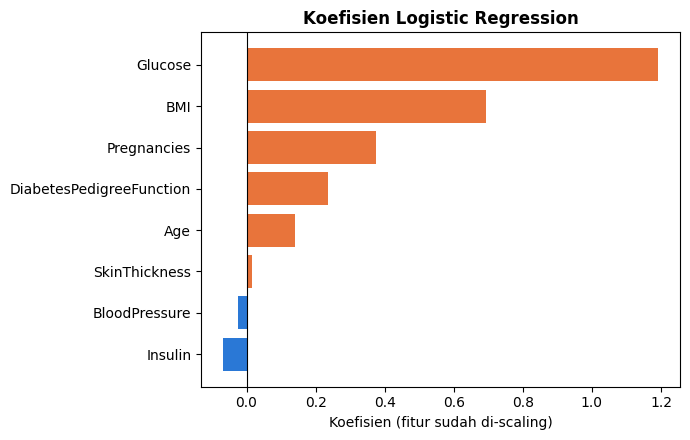

In [21]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print(coef.round(3).to_string())

plt.figure(figsize=(7, 4.5))
plt.barh(coef.index, coef.values, color=['#e8743b' if c > 0 else '#2a78d6' for c in coef.values])
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Koefisien (fitur sudah di-scaling)')
plt.title('Koefisien Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

**1. Data dan preprocessing**
Dataset berisi 768 pasien dengan 8 fitur numerik. Kelas tidak seimbang: 500 tidak diabetes (65.1%) dan 268 diabetes (34.9%). Model yang selalu menebak "tidak diabetes" sudah mendapat akurasi 65%, jadi akurasi saja tidak cukup untuk menilai model. Dataset Kaggle ini sudah tidak memiliki nilai 0. Nilai 0 sudah diganti oleh penyedia dataset dengan median per kelas Outcome (Insulin 102.5 hanya pada kelas 0 dan 169.5 hanya pada kelas 1). Ini adalah data leakage. Nilai tersebut dikembalikan menjadi missing (374 Insulin dan 247 SkinThickness), lalu diimputasi dengan median dari train set saja. Split 80:20 dengan stratify=y menghasilkan proporsi kelas 1 yang hampir sama pada train (0.349) dan test (0.351). StandardScaler hanya di-fit pada train set.

**2. EDA**
Glucose memiliki korelasi tertinggi terhadap Outcome (0.50). Rata-rata Glucose pasien diabetes sekitar 142, sedangkan non-diabetes sekitar 111. Pada heatmap, Insulin (0.38) dan SkinThickness (0.30) terlihat cukup berkorelasi dengan Outcome. Korelasi ini dibesar-besarkan oleh leakage dari imputasi median per kelas, sehingga tidak bisa dipercaya begitu saja. Beberapa fitur tidak berdistribusi normal. Insulin, DiabetesPedigreeFunction, dan Age miring ke kanan. Ini melanggar asumsi Gaussian Naive Bayes. Ada korelasi cukup tinggi antar fitur, misalnya Age dengan Pregnancies (0.54) dan BMI dengan SkinThickness (0.57). Ini melanggar asumsi independensi Naive Bayes.

**3. Perbandingan performa pada test set (154 sampel)**

| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC |
|---|---|---|---|---|---|
| Gaussian NB | 0.701 | 0.567 | 0.630 | 0.596 | 0.764 |
| Logistic Regression | 0.708 | 0.600 | 0.500 | 0.545 | 0.813 |

- Akurasi kedua model hampir sama. Logistic Regression sedikit lebih tinggi.
- Logistic Regression lebih baik dalam membedakan kelas secara keseluruhan, terlihat dari ROC AUC 0.813 dibanding 0.764. Precision-nya juga lebih tinggi, artinya prediksi "diabetes" lebih jarang salah.
- Gaussian NB memiliki recall lebih tinggi (0.63 vs 0.50). Dari confusion matrix, GNB mendeteksi 34 dari 54 pasien diabetes, sedangkan Logistic Regression hanya 27. Sebagai gantinya, GNB menghasilkan lebih banyak false positive (26 vs 18).
- Pada konteks medis, false negative (pasien diabetes tidak terdeteksi) biasanya lebih berbahaya. Dari sisi ini recall GNB lebih menguntungkan, walaupun kualitas ranking probabilitasnya lebih rendah.

**4. Tuning dan stabilitas**
GridSearchCV pada train set memilih C=1 dan class_weight=None, dengan akurasi cross validation 0.790. Akurasi test (0.708) lebih rendah dari akurasi cross validation (0.790). Test set hanya 154 sampel, sehingga satu split sangat dipengaruhi pembagian data. Perbedaan akurasi 0.007 antara kedua model setara dengan hanya 1 sampel dan tidak bisa dianggap signifikan.

**5. Interpretasi koefisien Logistic Regression**
Glucose memiliki koefisien terbesar (1.19), diikuti BMI (0.70), Pregnancies (0.37), DiabetesPedigreeFunction (0.24), dan Age (0.14). Semua fitur ini meningkatkan probabilitas diabetes. Insulin, BloodPressure, dan SkinThickness memiliki koefisien mendekati 0. Setelah leakage dihilangkan dan banyak nilainya diimputasi, fitur ini hampir tidak memberi informasi tambahan. Hasil ini konsisten dengan pengetahuan medis bahwa kadar glukosa dan BMI adalah faktor risiko utama diabetes.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan**
Kedua model mencapai akurasi sekitar 70% pada test set. Logistic Regression sedikit lebih unggul secara keseluruhan dengan ROC AUC 0.813 dan akurasi cross validation 0.790. Gaussian NB lebih baik dalam menemukan pasien diabetes (recall 0.63), tetapi dengan lebih banyak false positive. Asumsi independensi dan distribusi normalnya tidak sepenuhnya terpenuhi pada data ini. Glucose dan BMI adalah prediktor paling penting untuk diabetes. Dataset versi Kaggle ini mengandung data leakage dari imputasi median per kelas. Leakage ini perlu dihilangkan agar hasil evaluasi jujur.

**Saran**
Gunakan repeated stratified k-fold cross validation untuk membandingkan model, karena satu split dengan 154 sampel test kurang stabil. Jika recall lebih penting, turunkan threshold probabilitas Logistic Regression (misalnya 0.3–0.4) atau gunakan class_weight='balanced'.
Coba transformasi log pada fitur yang miring (Insulin, DiabetesPedigreeFunction, Age) agar lebih sesuai dengan asumsi Gaussian NB. Coba imputasi yang lebih baik seperti KNNImputer atau IterativeImputer untuk Insulin dan SkinThickness yang banyak missing. Bandingkan dengan model non-linear seperti Random Forest atau Gradient Boosting sebagai baseline tambahan.